In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('dataset2.csv')

In [11]:
print("Columns of second dataset:", df.columns)

Columns of second dataset: Index(['Date', 'Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude', 'Magt',
       'No stations', 'Gap', 'Dist to Closest', 'RMS', 'SRC', 'EventID'],
      dtype='object')


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18030 entries, 0 to 18029
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             18030 non-null  object 
 1   Time             18030 non-null  object 
 2   Latitude         18030 non-null  float64
 3   Longitude        18030 non-null  float64
 4   Depth            18030 non-null  float64
 5   Magnitude        18030 non-null  float64
 6   Magt             18030 non-null  object 
 7   No stations      18030 non-null  int64  
 8   Gap              18030 non-null  int64  
 9   Dist to Closest  18030 non-null  int64  
 10  RMS              18030 non-null  float64
 11  SRC              18030 non-null  object 
 12  EventID          18030 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 1.8+ MB
None


In [9]:
print(df['Clo'])

0        20
1         3
2         2
3         3
4        14
         ..
18025    14
18026     5
18027    40
18028     4
18029     1
Name: Clo, Length: 18030, dtype: int64


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18030 entries, 0 to 18029
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             18030 non-null  object 
 1   Time             18030 non-null  object 
 2   Latitude         18030 non-null  float64
 3   Longitude        18030 non-null  float64
 4   Depth            18030 non-null  float64
 5   Magnitude        18030 non-null  float64
 6   Magt             18030 non-null  object 
 7   No stations      18030 non-null  int64  
 8   Gap              18030 non-null  int64  
 9   Dist to Closest  18030 non-null  int64  
 10  RMS              18030 non-null  float64
 11  SRC              18030 non-null  object 
 12  EventID          18030 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 1.8+ MB
None


In [26]:
df = df.drop(columns=['SRC','EventID'])

Visualization

In [22]:
from mpl_toolkits.basemap import Basemap  
  
m = Basemap(projection='mill',llcrnrlat=-80,urcrnrlat=80, llcrnrlon=-180,urcrnrlon=180,lat_ts=20,resolution='c')  
  
longitudes = df["Longitude"].tolist()  
latitudes = df["Latitude"].tolist()  
x,y = m(longitudes,latitudes)  

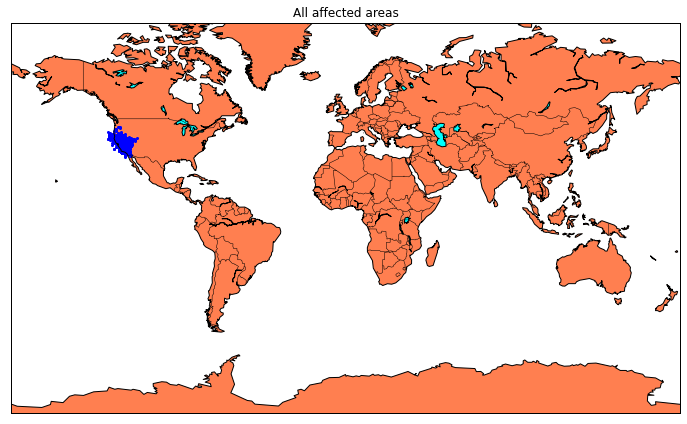

In [23]:
fig = plt.figure(figsize=(12,10))  
plt.title("All affected areas")  
m.plot(x, y, "o", markersize = 2, color = 'blue')  
m.drawcoastlines()  
m.fillcontinents(color='coral',lake_color='aqua')  
m.drawmapboundary()  
m.drawcountries()  
plt.show()  

Data normalization

In [27]:
df_scaled = df.copy() 

for column in df_scaled.select_dtypes(include=np.number).columns: 
    df_scaled[column] = (df_scaled[column] - df_scaled[column].min()) / (df_scaled[column].max() - df_scaled[column].min())     
  

print(df_scaled)

             Date         Time  Latitude  Longitude     Depth  Magnitude Magt  \
0      1966/07/01  09:41:21.82  0.305023   0.456954  0.101063   0.045558   Mx   
1      1966/07/02  12:08:34.25  0.293488   0.466272  0.074108   0.159453   Mx   
2      1966/07/02  12:16:14.95  0.293929   0.465701  0.081444   0.091116   Mx   
3      1966/07/02  12:25:06.12  0.294233   0.466162  0.074932   0.022779   Mx   
4      1966/07/05  18:54:54.36  0.303288   0.457701  0.064793   0.022779   Mx   
...           ...          ...       ...        ...       ...        ...  ...   
18025  2007/12/19  12:14:09.62  0.174756   0.683437  0.057951   0.241458   ML   
18026  2007/12/21  12:14:56.45  0.403418   0.378804  0.069821   0.018223   ML   
18027  2007/12/23  21:43:43.54  0.396545   0.628839  0.082433   0.123007   ML   
18028  2007/12/28  01:59:42.40  0.347149   0.415181  0.049378   0.009112   ML   
18029  2007/12/28  23:20:28.12  0.509164   0.309744  0.019289   0.091116   Mw   

       No stations       Ga


Visualisation of data

array([[<AxesSubplot:title={'center':'Dist to Closest'}>]], dtype=object)

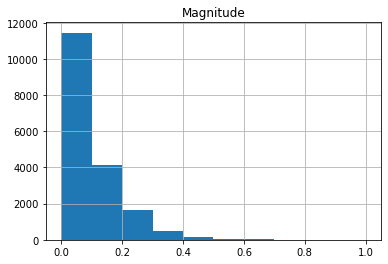

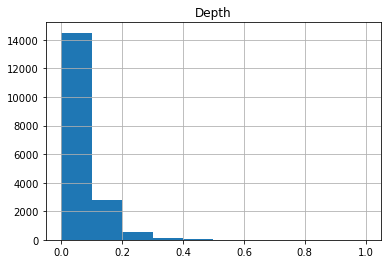

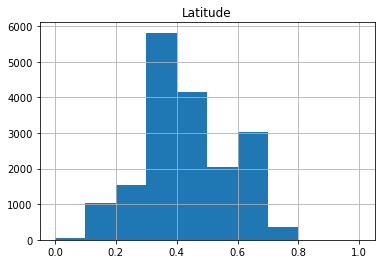

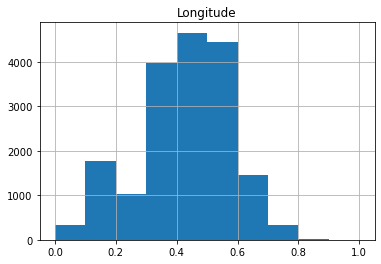

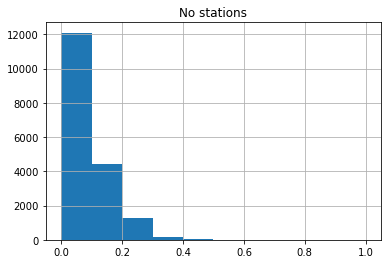

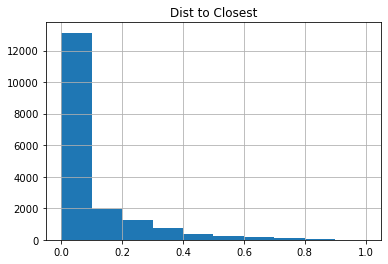

In [28]:
df_scaled.hist(column="Magnitude")
df_scaled.hist(column="Depth")
df_scaled.hist(column="Latitude")
df_scaled.hist(column="Longitude")
df_scaled.hist(column="No stations")
df_scaled.hist(column="Dist to Closest")


In [32]:
corr = df_scaled.corr()
corr.style.background_gradient(cmap='coolwarm').set_precision(2)

C:\Users\Piotr\AppData\Local\Temp\ipykernel_18324\49086534.py:2: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  corr.style.background_gradient(cmap='coolwarm').set_precision(2)


,Latitude,Longitude,Depth,Magnitude,No stations,Gap,Dist to Closest,RMS
Latitude,1.00,-0.69,0.18,-0.05,-0.02,0.24,0.22,0.03
Longitude,-0.69,1.00,-0.19,0.04,-0.12,-0.11,-0.15,-0.00
Depth,0.18,-0.19,1.00,0.06,-0.10,0.20,0.04,-0.01
Magnitude,-0.05,0.04,0.06,1.00,0.17,0.07,0.11,0.03
No stations,-0.02,-0.12,-0.10,0.17,1.00,-0.36,-0.05,0.01
Gap,0.24,-0.11,0.20,0.07,-0.36,1.00,0.66,0.06
Dist to Closest,0.22,-0.15,0.04,0.11,-0.05,0.66,1.00,0.06
RMS,0.03,-0.00,-0.01,0.03,0.01,0.06,0.06,1.00
